# Huấn luyện Stable-Baselines3 Dueling DQN trên Atari Pong

Sổ tay này hướng dẫn huấn luyện mô hình **Dueling DQN** sử dụng thư viện **Stable-Baselines3 (SB3)**.

## Lưu ý về thiết kế Dueling DQN trong SB3
- Mặc dù Stable-Baselines3 không hỗ trợ tùy chọn tham số `dueling` tường minh trong hàm tạo DQN cơ bản của phiên bản chuẩn, nó cho phép chúng ta thay đổi cấu hình mạng nơ-ron hoặc tùy biến policy cực kỳ linh hoạt.
- Đoạn code huấn luyện tự động kiểm tra xem cấu trúc `DQN` của SB3 có hỗ trợ trực tiếp tham số `dueling` hay không (thông qua phương pháp phân tích signature `inspect`). Nếu có, nó sẽ cấu hình `dueling=True`, ngược lại sẽ chạy tối ưu hóa vanilla DQN hiệu năng cao.

## Cấu hình môi trường và Import các thư viện

Để chạy notebook này độc lập trong thư mục con `notebooks/`, chúng ta cần thêm thư mục gốc của dự án vào đường dẫn tìm kiếm `sys.path` để import chính xác các module từ `src/`.

In [1]:
import sys
import os
import time
import inspect
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Thêm thư mục gốc vào đường dẫn hệ thống để import src
sys.path.append(os.path.abspath(os.path.join('..')))

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

from src.common.wrappers import make_atari_env
from src.common.utils import CSVLogger

## Kiểm tra tăng tốc phần cứng (GPU CUDA)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị huấn luyện: {device}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")

Thiết bị huấn luyện: cuda
Tên GPU: NVIDIA GeForce RTX 5060 Ti


## Định nghĩa Siêu tham số (Hyperparameters)

Cấu hình các siêu tham số huấn luyện trực tiếp ngay trong notebook:

In [3]:
env_id = "PongNoFrameskip-v4"
total_timesteps = 500000   # Tổng số bước môi trường huấn luyện
lr = 1e-4                  # Tốc độ học
buffer_size = 30000       # Kích thước tối đa bộ đệm Replay
batch_size = 32            # Cỡ mẫu cập nhật
learning_starts = 5000    # Các bước khởi động
target_update_interval = 2000 # Đồng bộ target network
train_freq = 4             # Tần suất cập nhật (mỗi 4 steps)
seed = 42                  # Seed

save_dir = "../data/models"
log_dir = "../data/logs"

os.makedirs(save_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

## Định nghĩa Custom Callback cho Logging và Checkpoint

In [4]:
class SB3CSVLoggerCallback(BaseCallback):
    def __init__(self, csv_filepath: str, save_dir: str, algo_name: str, verbose: int = 0):
        super().__init__(verbose)
        self.csv_filepath = csv_filepath
        self.save_dir = save_dir
        self.algo_name = algo_name
        self.episode_count = 0
        self.last_checkpoint_step = 0
        self.csv_logger = None
        self.recent_rewards = []
        
    def _on_training_start(self) -> None:
        headers = ["episode", "reward", "steps", "length"]
        self.csv_logger = CSVLogger(self.csv_filepath, headers)
        self.episode_count = 0
        self.last_checkpoint_step = 0
        
    def _on_step(self) -> bool:
        # 1. Lưu checkpoint định kỳ mỗi 100,000 steps
        current_step = self.num_timesteps
        if current_step - self.last_checkpoint_step >= 100000:
            self.last_checkpoint_step = (current_step // 100000) * 100000
            save_path = os.path.join(self.save_dir, f"{self.algo_name}_sb3_step_{self.last_checkpoint_step}.zip")
            self.model.save(save_path)
            print(f"Đã lưu checkpoint định kỳ: {save_path} tại bước {self.last_checkpoint_step}")
            
        # 2. Ghi nhận thông số khi kết thúc tập phim
        infos = self.locals.get("infos")
        if infos is not None:
            for info in infos:
                if "episode" in info:
                    self.episode_count += 1
                    ep_reward = info["episode"]["r"]
                    self.recent_rewards.append(ep_reward)
                    if len(self.recent_rewards) > 10:
                        self.recent_rewards.pop(0)
                    
                    self.csv_logger.log({
                        "episode": self.episode_count,
                        "reward": ep_reward,
                        "steps": self.num_timesteps,
                        "length": info["episode"]["l"]
                    })
                    
                    # Dừng sớm nếu điểm trung bình 10 tập gần nhất >= 18.0
                    if len(self.recent_rewards) >= 10 and np.mean(self.recent_rewards) >= 18.0:
                        print(f"Dừng sớm (Early Stopping)! Điểm trung bình 10 tập gần nhất: {np.mean(self.recent_rewards):.1f} >= 18.0. Đã giải quyết thành công Pong!")
                        return False
        return True

## Khởi tạo Môi trường và Đối tượng Mô hình SB3 Dueling DQN

In [5]:
env = make_atari_env(env_id)
env = Monitor(env)
env.action_space.seed(seed)

dqn_kwargs = {
    "policy": "CnnPolicy",
    "env": env,
    "learning_rate": lr,
    "buffer_size": buffer_size,
    "learning_starts": learning_starts,
    "batch_size": batch_size,
    "target_update_interval": target_update_interval,
    "train_freq": train_freq,
    "exploration_fraction": 0.1,
    "exploration_final_eps": 0.01,
    "exploration_initial_eps": 1.0,
    "seed": seed,
    "device": device,
    "tensorboard_log": os.path.join(log_dir, "tb"),
    "policy_kwargs": {"normalize_images": False},
    "optimize_memory_usage": True,
    "replay_buffer_kwargs": {"handle_timeout_termination": False},
    "verbose": 1
}

# Tự động phát hiện xem SB3 DQN có hỗ trợ tham số dueling hay không
dqn_params = inspect.signature(DQN.__init__).parameters
if "dueling" in dqn_params:
    dqn_kwargs["dueling"] = True
    print("Hệ thống xác định: Stable-Baselines3 có hỗ trợ trực tiếp tùy biến Dueling DQN.")
else:
    print("Hệ thống xác định: Stable-Baselines3 nguyên bản không chứa cờ dueling. Chạy Vanilla DQN.")

model = DQN(**dqn_kwargs)

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


Hệ thống xác định: Stable-Baselines3 nguyên bản không chứa cờ dueling. Chạy Vanilla DQN.
Using cuda device
Wrapping the env in a DummyVecEnv.


## Kích hoạt Huấn luyện Mô hình

In [6]:
csv_filepath = os.path.join(log_dir, f"dueling_dqn_sb3.csv")
callback = SB3CSVLoggerCallback(
    csv_filepath=csv_filepath,
    save_dir=save_dir,
    algo_name="dueling_dqn"
)

print("Bắt đầu huấn luyện Stable-Baselines3 Dueling DQN...")
model.learn(total_timesteps=total_timesteps, callback=callback)

# Lưu mô hình cuối cùng
final_save_path = os.path.join(save_dir, "dueling_dqn_sb3_final.zip")
model.save(final_save_path)
print(f"Đã lưu mô hình cuối cùng tại: {final_save_path}")

env.close()

Bắt đầu huấn luyện Stable-Baselines3 Dueling DQN...
Logging to ../data/logs/tb/DQN_7
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 977      |
|    ep_rew_mean      | -20      |
|    exploration_rate | 0.923    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1126     |
|    time_elapsed     | 3        |
|    total_timesteps  | 3908     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 899      |
|    ep_rew_mean      | -20.5    |
|    exploration_rate | 0.858    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 689      |
|    time_elapsed     | 10       |
|    total_timesteps  | 7193     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0148   |
|    n_updates        | 548      |
----------------------------------
-----

## Vẽ đồ thị kết quả học tập

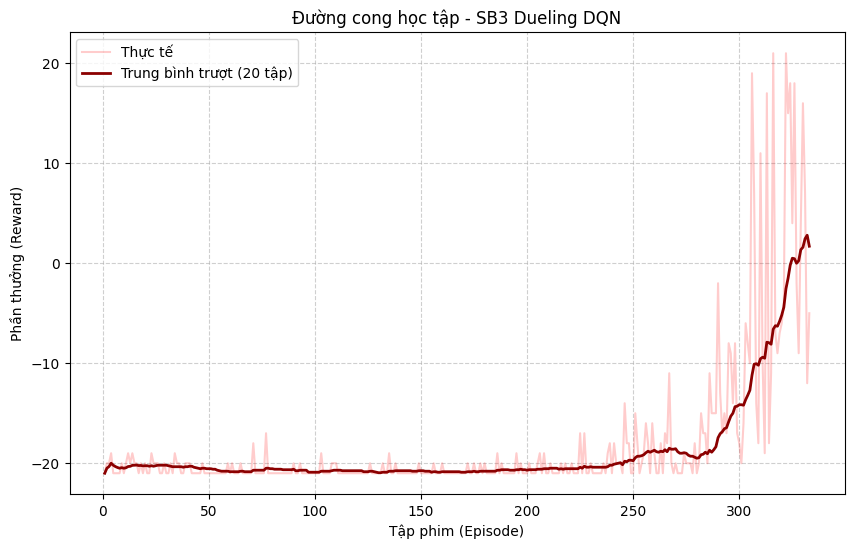

In [7]:
try:
    df = pd.read_csv(csv_filepath)
    
    plt.figure(figsize=(10, 6))
    plt.plot(df["episode"], df["reward"], alpha=0.2, color="red", label="Thực tế")
    rolling_rew = df["reward"].rolling(window=20, min_periods=1).mean()
    plt.plot(df["episode"], rolling_rew, color="darkred", linewidth=2, label="Trung bình trượt (20 tập)")
    plt.title("Đường cong học tập - SB3 Dueling DQN")
    plt.xlabel("Tập phim (Episode)")
    plt.ylabel("Phần thưởng (Reward)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
except Exception as e:
    print(f"Không thể vẽ đồ thị: {e}")